# 네이버 영화 리뷰 감성 분석

!curl -L -o ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt  # 학습용 데이터 파일 다운로드
!curl -L -o ratings_test.txt  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt   # 테스트용 데이터 파일 다운로드

In [25]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from konlpy.tag import Okt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

okt = Okt()

with open(
    r"C:\Users\SJ\OneDrive\Desktop\study\NLP\04_sequence_model.ipynb\ko_stopwords.txt",
    "r",
    encoding="utf-8"
) as file:
    ko_stopwords = set(file.read().split())

print("Okt 준비 완료")
print("불용어 개수:", len(ko_stopwords))

Okt 준비 완료
불용어 개수: 646


In [26]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from konlpy.tag import Okt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

okt = Okt()

with open(
    r"C:\Users\SJ\OneDrive\Desktop\study\NLP\04_sequence_model.ipynb\ko_stopwords.txt",
    "r",
    encoding="utf-8"
) as file:
    ko_stopwords = set(file.read().split())

print("Okt 준비 완료")
print("불용어 개수:", len(ko_stopwords))

Okt 준비 완료
불용어 개수: 646


In [27]:
!curl -L -o ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt  # 학습용 데이터 파일 다운로드
!curl -L -o ratings_test.txt  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt   # 테스트용 데이터 파일 다운로드

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 13.95M 100 13.95M   0      0 13.79M      0   00:01   00:01              0
100 13.95M 100 13.95M   0      0 13.78M      0   00:01   00:01              0
100 13.95M 100 13.95M   0      0 13.78M      0   00:01   00:01              0
curl: (3) URL rejected: No host part in the URL
curl: (6) Could not resolve host: xn--ru4bi6eisq
curl: (6) Could not resolve host: xn--2n1bp39av7g
curl: (6) Could not resolve host: xn--pu5bl5s
curl: (6) Could not resolve host: xn--2j1bj1b12ewtu
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  4.66M 100  4.66M   0      0 10.94M      0     

In [28]:
# 기본 라이브러리
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 진행률 표시
from tqdm.auto import tqdm

# 한국어 형태소 분석
from konlpy.tag import Okt

# 토큰화 및 패딩
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [29]:
import pandas as pd
ratings_train_df = pd.read_csv('ratings_train.txt', sep = '\t')
ratings_test_df = pd.read_csv('ratings_train.txt', sep = '\t')

ratings_train_df.shape, ratings_test_df.shape

((150000, 3), (150000, 3))

In [30]:
# 데이터 샘플링 (학습시간 단축, 메모리 사용량 감안)
ratings_train_df = ratings_train_df.sample(n = 50000, random_state = 42)
ratings_test_df = ratings_test_df.sample(n = 5000, random_state = 42)

ratings_train_df.shape, ratings_test_df.shape

((50000, 3), (5000, 3))

In [31]:
import re
from konlpy.tag import Okt

okt = Okt()

with open("ko_stopwords.txt", "r", encoding="utf-8") as file:
    ko_stopwords = set(file.read().split())


def preprocessing(text):
    text = str(text)

    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = text.replace("\t", " ")

    text = re.sub(r"[^가-힣 ]", "", text)
    text = re.sub(r" +", " ", text).strip()

    tokens = okt.morphs(text, stem=True)

    tokens = [
        token for token in tokens
        if token not in ko_stopwords
    ]

    return tokens

In [32]:

sample = """
    이런 영화 진짜 fantastic!!
    너무 못만들었다.
    그런데 감동이다!!!
"""

preprocessing(sample)

['이렇다', '영화', '진짜', '너무', '못', '만들다', '감동', '이다']

In [33]:
# 텍스트 전처리하고, 학습/테스트 리스트 생성
from tqdm.auto import tqdm

X_train, y_train, X_test, y_test = [], [], [], []

for index, row in tqdm(ratings_train_df.iterrows()):  # df의 행단위 순회
    doc, label = row['document'], row['label']
    X_train.append(preprocessing(doc))  # X 데이터는 전처리 후 수집
    y_train.append(label)

for index, row in tqdm(ratings_test_df.iterrows()):
    doc, label = row['document'], row['label']
    X_test.append(preprocessing(doc))
    y_test.append(label)

print(len(X_train), len(y_train), len(X_test), len(y_test))

0it [00:00, ?it/s]

0it [00:00, ?it/s]

50000 50000 5000 5000


In [34]:
print(X_train[:3])
print(y_train[:3])

print(X_test[:3])
print(y_test[:3])

[['수만', '보다'], ['일방', '적', '영화', '다', '관객', '고려', '해주다'], ['세상', '초월', '사람', '선하다', '마음']]
[1, 0, 1]
[['수만', '보다'], ['일방', '적', '영화', '다', '관객', '고려', '해주다'], ['세상', '초월', '사람', '선하다', '마음']]
[1, 0, 1]


In [35]:
# 토큰화 기반 정수 인코딩 준비 및 시퀀스 변환
from tensorflow.keras.preprocessing.text import Tokenizer # 텍스트 -> 정수 시퀀스 변환 도구
from tensorflow.keras.preprocessing.sequence import pad_sequences # 패딩(길이 통일) 도구

vocab_size = 20_000 # 단어 사전 크기 (빈도 기준 상위 2만개)

tokenizer = Tokenizer(num_words = vocab_size, oov_token = '<OOV>') # 사전에 없는 단어는 OOV 처리

tokenizer.fit_on_texts(X_train) # 학습 데이터로 단어 사전(word_index) 학습 생성
X_train_encoded = tokenizer.texts_to_sequences(X_train) # 학습 텍스트를 정수 시퀀스로 변환
X_test_encoded = tokenizer.texts_to_sequences(X_test)

print(X_train_encoded[:3])
print(X_test_encoded[:3])

[[10688, 3], [6440, 13, 2, 10, 309, 4135, 111], [294, 2593, 27, 3296, 121]]
[[10688, 3], [6440, 13, 2, 10, 309, 4135, 111], [294, 2593, 27, 3296, 121]]


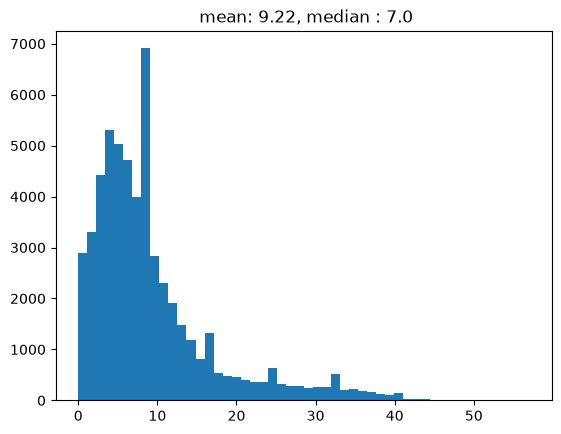

In [36]:
# 패딩 적정 길이 조사
import matplotlib.pyplot as plt
import numpy as np

X_train_len = [len(seq) for seq in X_train_encoded] # 각 샘플 시퀀스 길이 리스트
X_test_len = [len(seq) for seq in X_test_encoded] # 각 샘플 시퀀스 길이 리스트

mean = np.mean(X_train_len + X_test_len)    # 시퀀스 길이 평균
median = np.median(X_train_len+X_test_len) # 시퀀스 길이 중앙값

# 히스토그램으로 시각화 
plt.hist(X_train_len+ X_test_len, bins = 50)            
plt.title(f" mean: {mean:.2f}, median : {median}")
plt.show()

In [37]:
max_len =15

X_train_padded = pad_sequences(X_train_encoded, maxlen = max_len) # max_len 기준 패딩 / 자르기
X_test_padded = pad_sequences(X_test_encoded, maxlen = max_len)   # max_len 기준 패딩 / 자르기

In [38]:
# 정수 시퀀스를 단어로 복원해 사람이 읽을 수 있는 형태로 변환
def decode_sentence(encoded_sentence):
    # 정수 시퀀스를 찾아 해당 인덱스의 단어를 반환 (없으면 _)
    decoded = [tokenizer.index_word.get(n, '_') for n in encoded_sentence]
    return ' '.join(decoded)               # 하나의 문자열로 반환

print(X_train_padded[0])                   # 패딩처리 완료된 정수 시퀀스
print(decode_sentence(X_train_padded[0]))  # 원래의 단어 형태로 복원

print(ratings_test_df.iloc[0,1])           # test 데이터 0번째 리뷰(document) 원문
print(X_test_padded[0])
print(decode_sentence(X_test_padded[0]))

[    0     0     0     0     0     0     0     0     0     0     0     0
     0 10688     3]
_ _ _ _ _ _ _ _ _ _ _ _ _ 수만 보다
수OO만에 다시보네여
[    0     0     0     0     0     0     0     0     0     0     0     0
     0 10688     3]
_ _ _ _ _ _ _ _ _ _ _ _ _ 수만 보다


# 모델 설계

In [39]:
import torch
import torch.nn as nn  # 수정: as nn 추가

# 양방향 LSTM 분류 모델: 임베딩 -> 양방향 LSTM -> FC로 감성(이진)분석 logit을 출력하는 모델
class BiLSTMSentimentNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):  # 수정
        super().__init__()  # 수정

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        x = self.embedding(x)            # (B, T) -> (B, T, E)
        _, (hidden, _) = self.lstm(x)    # output: (B, T, 2H), hidden: (2, B, H)

        forward_pass = hidden[-2]        # (B, H)
        backward_pass = hidden[-1]       # (B, H)
        hidden_merged = torch.cat((forward_pass, backward_pass), dim=1)

        output = self.fc(hidden_merged)  # (B, 2H) -> (B, 1)
        return output


model = BiLSTMSentimentNet(
    vocab_size,
    embedding_dim=100,
    hidden_dim=128
)

model


BiLSTMSentimentNet(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

In [40]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
BiLSTMSentimentNet                       --
├─Embedding: 1-1                         2,000,000
├─LSTM: 1-2                              235,520
├─Linear: 1-3                            257
Total params: 2,235,777
Trainable params: 2,235,777
Non-trainable params: 0

# 모델 학습

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim

# pytorch Tensor 형태로 변환 (X 데이터는 LongTensor, y데이터는 FloatTensor)
X_train_padded = torch.tensor(X_train_padded, dtype = torch.long)
X_test_padded = torch.tensor(X_train_padded, dtype = torch.long)

# 라벨데이터는 2차원 형태 (N, ) -> (N, 1)
y_train = torch.tensor(y_train, dtype = torch.float).unsqueeze(1)
y_test = torch.tensor(y_train, dtype = torch.float).unsqueeze(1)

print(X_train_padded.shape, X_test_padded.shape)
print(y_train.shape, y_test.shape)

torch.Size([50000, 15]) torch.Size([50000, 15])
torch.Size([50000, 1]) torch.Size([50000, 1, 1])


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_81996\503587848.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_padded = torch.tensor(X_train_padded, dtype = torch.long)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_81996\503587848.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_train, dtype = torch.float).unsqueeze(1)


In [42]:
# 학습 데이터 준비
# DataLoader 구성
from torch.utils.data import random_split, DataLoader, TensorDataset
batch_size = 64
train_size = int(len(X_train_padded) * 0.8) # 80% 학습데이터
val_size = len(X_train_padded) - train_size # 나머지 20% 학습데이터

# 학습 / 검증 데이터셋 분리 (X, y 데이터 묶은 후에 랜덤 분리) / 테스트 데이터셋 생성
train_dataset, val_dataset = random_split(
    TensorDataset(X_train_padded, y_train), [train_size, val_size]
)
test_dataset = TensorDataset(X_test_padded, y_test)

# 학습용 : 섞어서 배치 생성 / 검증용 : 순서 유지 / 테스트용 : 순서 유지
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size = batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

print(len(train_dataset), len(val_dataset), len(test_dataset))
print(len(train_dataloader), len(val_dataloader), len(test_dataloader))

40000 10000 50000
625 157 782


In [43]:
# 학습 준비
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device : {device}')

torch.cuda.empty_cache()
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

epochs = 100
train_losses, val_losses, train_accs, val_accs = [], [], [], []

early_stopping_patience = 5
best_val_loss = float('inf')
early_stopping_counter = 0


device : cpu


In [44]:
from tqdm.auto import tqdm

# 학습
for epoch in tqdm(range(epochs)):
    total_loss, correct, total = 0, 0, 0

    # 학습
    model.train()
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.detach().cpu().item()
        p = torch.sigmoid(output)
        pred = (p >= 0.5).float()
        correct += (pred == labels).sum().float().detach().cpu().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_dataloader)
    train_losses.append(train_loss)
    train_acc = correct / total
    train_accs.append(train_acc)

    # 검증
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            output = model(val_inputs)
            loss = criterion(output, val_labels)

            val_loss += loss.detach().cpu().item()
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            val_correct += (pred == val_labels).sum().float().detach().cpu().item()
            val_total += len(val_labels)

    val_loss = val_loss / len(val_dataloader)
    val_losses.append(val_loss)
    val_acc = val_correct / val_total
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    lr = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch+1}/{epochs}: Train Loss : {train_loss:.4f}, Train Acc : {train_acc:.4f}, "
          f"Val Loss : {val_loss:.4f}, Val Acc : {val_acc:.4f}, lr : {lr}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print(f"{epoch + 1}에서 조기종료!")
            break


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100: Train Loss : 0.5167, Train Acc : 0.7346, Val Loss : 0.4399, Val Acc : 0.7888, lr : 0.001
Epoch 2/100: Train Loss : 0.3913, Train Acc : 0.8195, Val Loss : 0.4120, Val Acc : 0.8062, lr : 0.001
Epoch 3/100: Train Loss : 0.3170, Train Acc : 0.8615, Val Loss : 0.4178, Val Acc : 0.8106, lr : 0.001
Epoch 4/100: Train Loss : 0.2415, Train Acc : 0.8992, Val Loss : 0.4578, Val Acc : 0.8032, lr : 0.001
Epoch 5/100: Train Loss : 0.1643, Train Acc : 0.9365, Val Loss : 0.5477, Val Acc : 0.8049, lr : 0.001
Epoch 6/100: Train Loss : 0.1064, Train Acc : 0.9594, Val Loss : 0.6336, Val Acc : 0.7990, lr : 0.0005
Epoch 7/100: Train Loss : 0.0600, Train Acc : 0.9778, Val Loss : 0.7364, Val Acc : 0.7991, lr : 0.0005
7에서 조기종료!


In [48]:
import re

# 여러 문장을 받아 전처리 -> 인코딩 -> 패딩 -> 모델 추론으로 긍.부정 반환
def movie_review_sentimental_analysis(sentences):
    encoded_sequences = []

    tokens = [preprocessing(sent) for sent in sentences]
    encoded_sequences = tokenizer.texts_to_sequences(tokens)
    padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len)

    X = torch.tensor(padded_sequences, dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        output = model(X)
        p = torch.sigmoid(output)
        pred = (p >= 0.5).float()

        return [
            "긍정" if pr.item() == 1 else "부정"
            for pr in pred
        ]


samples = [
    "이 영화는 정말 재미있고 감동적이었다.",
    "연기도 형편없고 이야기도 너무 지루했다.",
    "오랜만에 정말 재미있게 본 영화다.",
    "시간이 아까울 정도로 최악이었다.",
    "흥미로웠지만 전개가 조금 느렸다."
]

movie_review_sentimental_analysis(samples)

['긍정', '부정', '긍정', '부정', '부정']